<a href="https://colab.research.google.com/github/anaberereta-hue/Trabajos-Colab/blob/main/Anis_taller_transformaciones_astro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install astroquery

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.9 MB/s eta 0:00:00


In [2]:
from astroquery.sdss import SDSS
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
from astropy.io import fits
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.visualization import make_lupton_rgb


In [3]:
#descargar una imagen del telescopio SDSS de una galaxia con coordenadas ra y dec, el tamaño de la imagen es de 30 arcsec
coord = SkyCoord(
    ra=201.649435*u.deg,
    dec=32.760895*u.deg,
    frame='icrs'
)

# Descargar imagen
images = SDSS.get_images(
    coordinates=coord,
    band='r'
)

hdu = images[0][0]

data = hdu.data
wcs = WCS(hdu.header)

# Recorte de 30 arcsec x 30 arcsec
cutout = Cutout2D(
    data,
    position=coord,
    size=(30*u.arcsec, 30*u.arcsec),
    wcs=wcs
)

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.


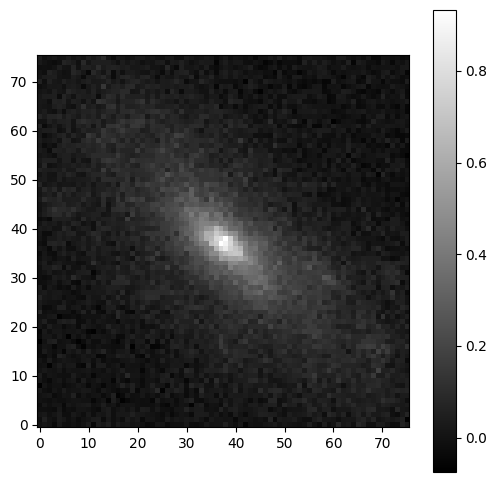

In [4]:
plt.figure(figsize=(6,6))
plt.imshow(cutout.data, origin='lower', cmap='gray')
plt.colorbar()
plt.show()

USA LA LIBRERIA MATPLOTLIB Y GRAFICA LA GALAXIA CON DIFERENTES MAPAS DE COLORES

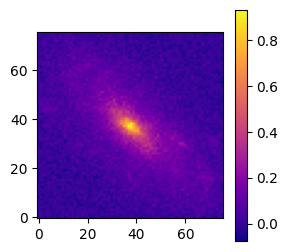

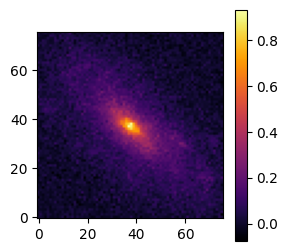

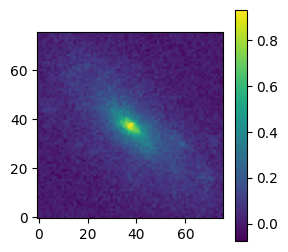

In [23]:
for cmap in ['plasma', 'inferno', 'viridis']:
    plt.figure(figsize=(3,3))
    plt.imshow(cutout.data, origin='lower', cmap=cmap)
    plt.colorbar()
    plt.show()

In [6]:
#los datos astronómicos vienen en un formato fits que almacena los metadatos asi como los datos
#en este código estamos seleccionando únicamente los datos de la imagen
image = cutout.data
display(image)

array([[-0.00361633,  0.01672363,  0.00146866, ..., -0.02398682,
         0.0625    ,  0.02688599],
       [-0.01379395,  0.05230713,  0.00146675, ...,  0.03198242,
         0.05743408, -0.06469727],
       [ 0.01164246,  0.02182007, -0.00871277, ..., -0.02401733,
         0.02178955,  0.07275391],
       ...,
       [-0.01396179, -0.00886536, -0.01396179, ..., -0.00889587,
         0.02163696,  0.0267334 ],
       [ 0.0267334 ,  0.001297  , -0.01396179, ...,  0.00636292,
        -0.00891113,  0.02163696],
       [ 0.04199219, -0.00888062,  0.01145935, ..., -0.0038147 ,
        -0.03942871, -0.02926636]], dtype='>f4')

A partir de los datos de la imagen estima la media, mediana, y desviación estándar de la imagen, también el valor mínimo y máximo

In [7]:
print("Media: ", np.mean(image))
print("Mediana: ", np.median(image))
print("Desviación estándar: ", np.std(image))
print("Valor mínimo: ", np.min(image))
print("Valor máximo: ", np.max(image))

Media:  0.06335631
Mediana:  0.042053223
Desviación estándar:  0.09240379
Valor mínimo:  -0.0748291
Valor máximo:  0.9326172


Grafica el histograma original de los datos de la imagen, cómo es la distribución?

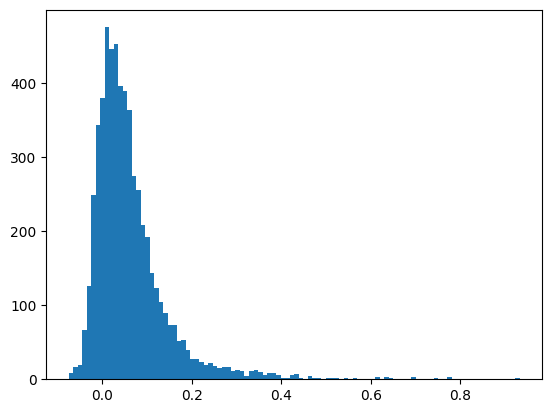

In [17]:
#Grafica el histograma original de los datos de la imagen, cómo es la distribución?
plt.hist(image.flatten(), bins=100)
plt.show()


Una de las transformaciones más empleadas en astronomía es la raíz cuadrada, transforma los datos empleando np.sqrt() y grafica la imagen transformada y su histograma.

/tmp/ipykernel_2256/1370116632.py:1: RuntimeWarning: invalid value encountered in sqrt
  nueva_img = np.sqrt(image)


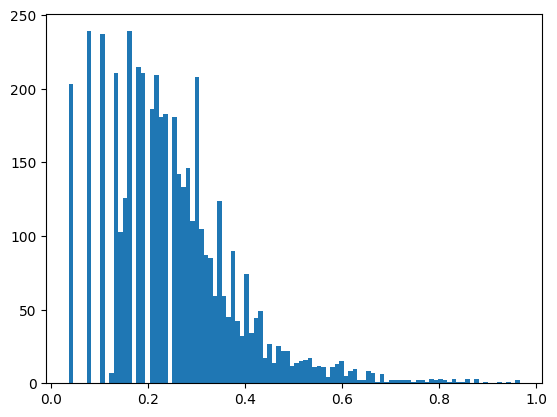

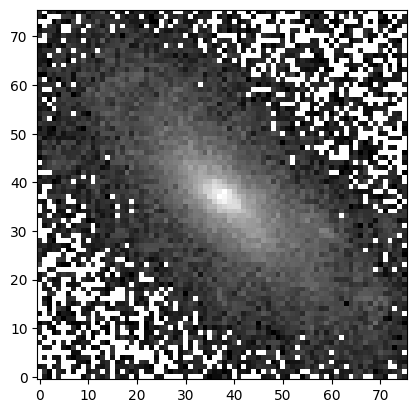

In [55]:
nueva_img = np.sqrt(image)
plt.hist(nueva_img.flatten(), bins=100)
plt.show()
plt.imshow(nueva_img, origin='lower', cmap='gray')

Una de las transformaciones más conocidas es la de logarítmo, transforma los datos empleando np.log1p() o np.log10(). Muestra la nueva gráfica y su histograma.

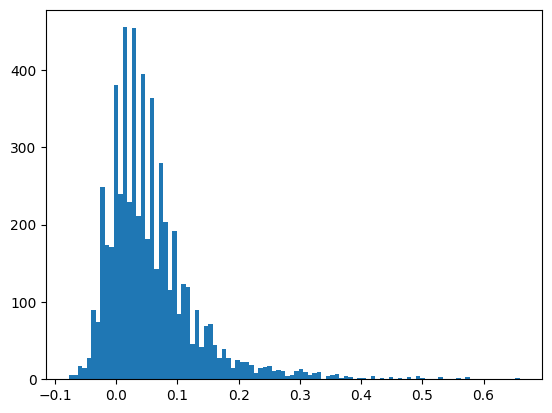

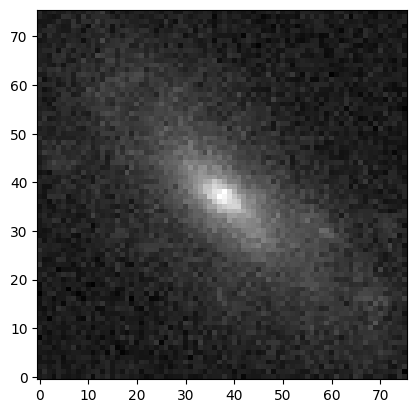

In [47]:
trans_image = np.log1p(image)
plt.hist(trans_image.flatten(), bins=100)
plt.show()
plt.imshow(trans_image, origin='lower', cmap='gray')

Construyen una gráfica que muestre las tres transformaciones. ¿cuál es la diferencia en las imágenes?

/tmp/ipykernel_2256/3539162461.py:8: RuntimeWarning: invalid value encountered in sqrt
  nueva_img = np.sqrt(image)


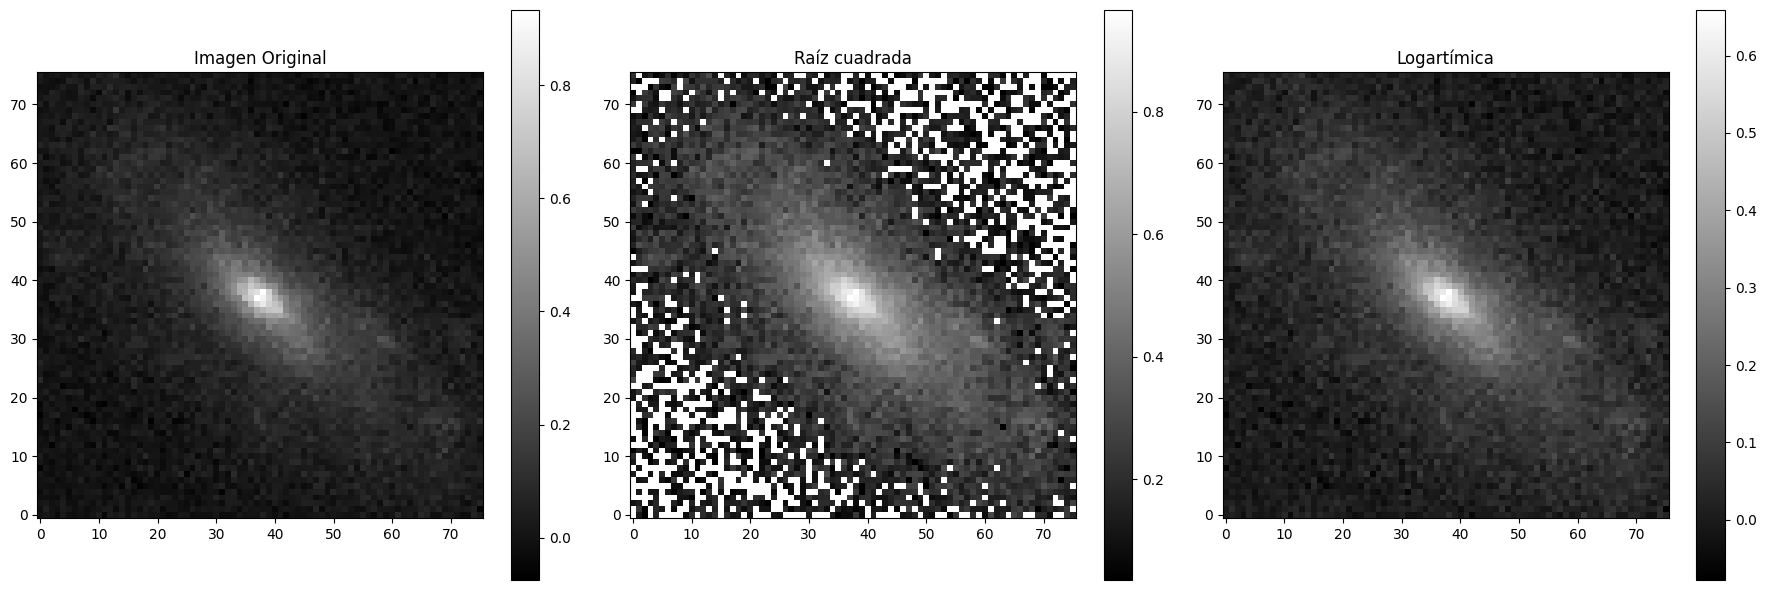

In [61]:
plt.figure(figsize=(18,6))

plt.subplot(1, 3, 1)
plt.imshow(image, origin='lower', cmap='gray')
plt.colorbar()
plt.title('Imagen Original')

nueva_img = np.sqrt(image)
plt.subplot(1, 3, 2)
plt.imshow(nueva_img, origin='lower', cmap='gray')
plt.colorbar()
plt.title('Raíz cuadrada')

trans_image = np.log1p(image)
plt.subplot(1, 3, 3)
plt.imshow(trans_image, origin='lower', cmap='gray')
plt.colorbar()
plt.title('Logartímica')

plt.tight_layout()
plt.show()

Imagen original: Esta muestra una imagen más llamativa, la mayor parte es netamente oscura con una parte brillante en el centro, como tal muestra son los datos en los que se ingresaron y funciona como imagen base.

Imagen Raíz cuadrada: Esta imagen se ve inestable al no ser como continua y tener saltos en los pixeles oscuros, muestra los valores más bajos que estaban en la imagen original es decir los valores negativos.

Imagen Logarítmica: Esta imagen es mucho más estable ya que no es tan intensa de forma visuale y muestra una ampliación de la imagen original y una visualizacion más clara y limpia.

Construyen una gráfica que muestre los tres histogramas . ¿cuál es la diferencia en los histogramas?

/tmp/ipykernel_2256/3183736174.py:8: RuntimeWarning: invalid value encountered in sqrt
  nueva_img = np.sqrt(image)


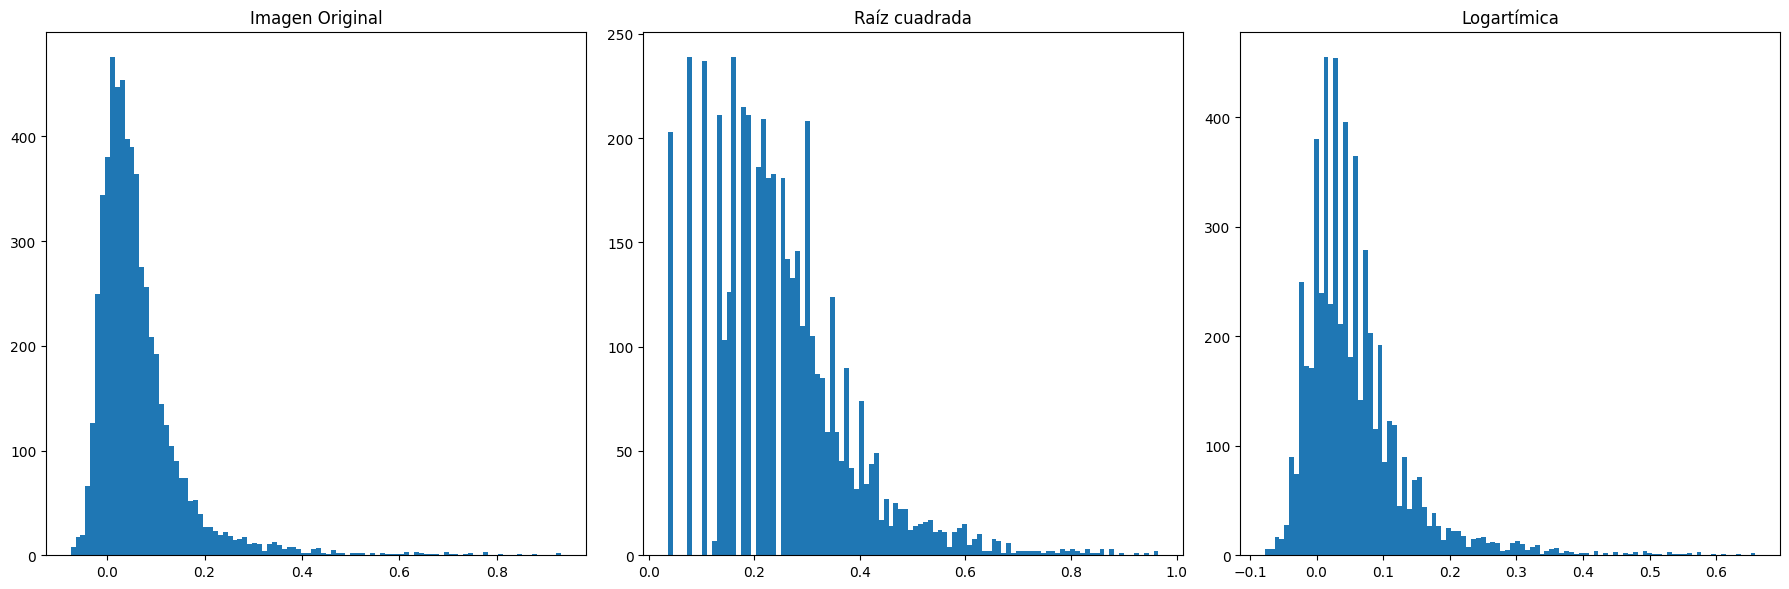

In [64]:
plt.figure(figsize=(18,6))

plt.subplot(1, 3, 1)
plt.hist(image.flatten(), bins=100)
plt.title('Imagen Original')


nueva_img = np.sqrt(image)
plt.subplot(1, 3, 2)
plt.hist(nueva_img.flatten(), bins=100)
plt.title('Raíz cuadrada')

trans_image = np.log1p(image)
plt.subplot(1, 3, 3)
plt.hist(trans_image.flatten(), bins=100)
plt.title('Logartímica')

plt.tight_layout()
plt.show()



Original: Muestra una disitribución sesgada a la izquierda, es decir que los pixles de bajos valores estan concentrados en aquella area, lo cual refleja que la galaxia es mayormente oscura segun la gráfica.

Raíz cuadrada: De igual forma es una distribucion sesgada, pero los pixeles oscuros se estiraron demasiado entre sí ya que sus valores cambiaron a difeencia de la original que eran casi similares.

Logarítmica: Esta tiene una forma más acampanada pero sigue siendo compacta a la izquierda y la cual se mantiene unida ya que no hace cambios bruscos entre los valores.

Estas son las transformaciones más conocidas, pero existen más, investiga una transformación distinta y contruye la gráfica y su histograma.

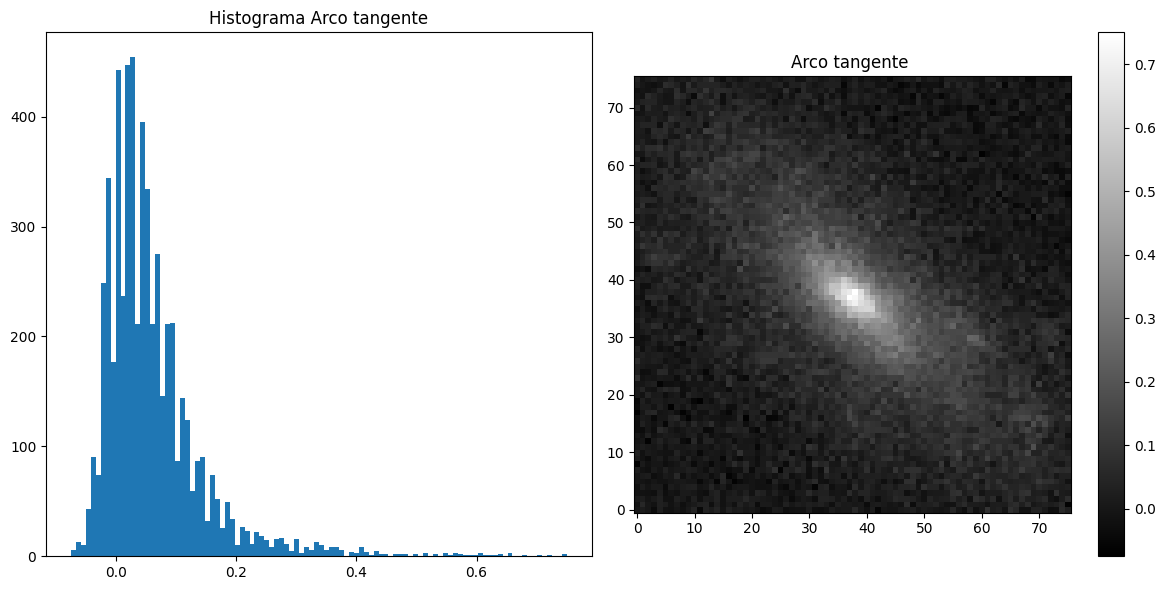

In [71]:
trans_image_arctan = np.arctan(image)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(trans_image_arctan.flatten(), bins=100)
plt.title('Histograma Arco tangente')

plt.subplot(1, 2, 2)
plt.imshow(trans_image_arctan, origin='lower', cmap='gray')
plt.colorbar()
plt.title('Arco tangente ')

plt.tight_layout()
plt.show()

Las transformaciones en astronomía se emplean para destacar las partes más tenues de los objetos. ¿Con cuál de todas te quedarías?


Me quedaría con la trasnformación logarítmica ya que es más estable que otras, ya que lo mantiene más limpio de forma visual, es decir que aclara el brillo de la imagen, además no hay saltos bruscos en los pixeles oscuros y se concentra en los valores positicos, permitiendo estudiar de forma correcta y eficaz la galaxia.

En astronomía para construir imágenes se emplean diferentes filtros,
* u → estrellas jóvenes calientes, formación estelar
* g → regiones azules, población joven
* r → estructura estelar general de galaxias
* i → bulbos galácticos, estrellas viejas
* z → polvo y componentes más rojos / galaxias lejanas


In [9]:
#este código permite descargar los datos de los otros filtros
bands = ['u', 'g', 'i','z']
cutouts = {}

for band in bands:
    img = SDSS.get_images(coordinates=coord, band=band)[0][0]

    data = img.data
    wcs = WCS(img.header)

    cut = Cutout2D(
        data,
        position=coord,
        size=(30*u.arcsec, 30*u.arcsec),
        wcs=wcs
    ).data

    cutouts[band] = cut

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.


In [10]:
cutouts

{'u': array([[ 0.00693512, -0.05224609,  0.04077148, ..., -0.03533936,
          0.06616211,  0.06616211],
        [-0.08605957, -0.00152016,  0.00693512, ..., -0.04382324,
         -0.10302734, -0.00151443],
        [ 0.0322876 , -0.01843262,  0.00693512, ...,  0.00694275,
         -0.00151443, -0.00151443],
        ...,
        [ 0.07458496, -0.02685547, -0.07763672, ..., -0.00994873,
          0.09155273,  0.03234863],
        [-0.03533936, -0.02685547, -0.05224609, ...,  0.02389526,
         -0.03533936,  0.04925537],
        [ 0.01542664,  0.01542664,  0.03234863, ..., -0.07763672,
          0.02389526, -0.00148201]], dtype='>f4'),
 'g': array([[ 0.02593994, -0.01420593, -0.03430176, ..., -0.01422119,
          0.01254272,  0.00250626],
        [ 0.00921631,  0.02929688,  0.02593994, ..., -0.00083923,
          0.00920105,  0.00585175],
        [-0.01086426, -0.02090454, -0.00416565, ...,  0.02593994,
          0.03265381, -0.00084019],
        ...,
        [ 0.01593018,  0.019287

Selecciona uno de los otros filtros y realiza la transformación de raíz cuadrada y logarítmica. Que puedes concluir de la transformación?